In [1]:
!pip -q install -U \
unsloth \
datasets \
sentence-transformers \
bert-score \
evaluate \
scikit-learn \
pandas \
matplotlib \
tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.2/72.2 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.8/77.8 MB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 596.7/596.7 kB 25.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 99.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 92.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 95.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.2

In [2]:
import os

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import gc
import re
import json
import time
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch

from datasets import load_dataset

from unsloth import FastLanguageModel
from unsloth.chat_templates import (train_on_responses_only,)

from trl import SFTTrainer, SFTConfig
from peft import PeftModel
from sentence_transformers import (SentenceTransformer,util)

from sklearn.metrics import accuracy_score
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

# ============================================================
# Reproducibility
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.set_float32_matmul_precision("high")


print("=" * 70)

print("Torch :", torch.__version__)
print("CUDA  :", torch.cuda.is_available())

if torch.cuda.is_available():

    print("GPU   :", torch.cuda.get_device_name(0))
    print("CUDA  :", torch.version.cuda)
    print("Memory:",round(torch.cuda.get_device_properties(0).total_memory / 1024**3,2,),"GB",)

print("=" * 70)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
Torch : 2.10.0+cu128
CUDA  : True
GPU   : Tesla T4
CUDA  : 12.8
Memory: 14.56 GB


In [3]:
# Model

BASE_MODEL = "unsloth/DeepSeek-R1-Distill-Llama-8B"
MAX_SEQ_LENGTH = 6144
LOAD_IN_4BIT = True
DTYPE = None

# Dataset

DATASET_PATH = "/kaggle/input/datasets/aryalunawat31/trainblue/train_blue.jsonl"

TRAIN_SPLIT = 0.80
VAL_SPLIT = 0.10
TEST_SPLIT = 0.10

# LoRA Hyperparameters

LORA_RANK = 64
LORA_ALPHA = 128
LORA_DROPOUT = 0.05

TARGET_MODULES = [
    "q_proj",
    "k_proj",
    "v_proj",
    "o_proj",
    "gate_proj",
    "up_proj",
    "down_proj",
]

# Training

BATCH_SIZE = 1
GRAD_ACCUM = 16
EPOCHS = 3
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.05
LOGGING_STEPS = 10
OUTPUT_DIR = "./outputs"
SAVE_STRATEGY = "epoch"
EVAL_STRATEGY = "epoch"
SAVE_TOTAL_LIMIT = 5

# Generation

MAX_NEW_TOKENS = 1024
TEMPERATURE = 0.1
TOP_P = 0.95
DO_SAMPLE = False

# Misc

SEED = 42

print("=" * 70)
print("Configuration Loaded")
print("=" * 70)
print(f"Model              : {BASE_MODEL}")
print(f"Context Length     : {MAX_SEQ_LENGTH}")
print(f"Epochs             : {EPOCHS}")
print(f"Batch Size         : {BATCH_SIZE}")
print(f"Gradient Accum     : {GRAD_ACCUM}")
print(f"Learning Rate      : {LEARNING_RATE}")
print("=" * 70)

Configuration Loaded
Model              : unsloth/DeepSeek-R1-Distill-Llama-8B
Context Length     : 6144
Epochs             : 3
Batch Size         : 1
Gradient Accum     : 16
Learning Rate      : 0.0001


In [4]:
# ============================================================
# Load Base Model
# ============================================================

model, tokenizer=FastLanguageModel.from_pretrained(
    model_name=BASE_MODEL,
    max_seq_length=MAX_SEQ_LENGTH,
    dtype=DTYPE,
    load_in_4bit=True,
    device_map={"": torch.cuda.current_device()},)

model.config.use_cache=False

print("=" * 70)
print("Base Model Loaded Successfully")
print("=" * 70)

print(f"Model          : {BASE_MODEL}")
print(f"Tokenizer       : {tokenizer.name_or_path}")
print(f"Vocabulary Size : {tokenizer.vocab_size}")
print(f"Max Context     : {MAX_SEQ_LENGTH}")

print("=" * 70)

==((====))==  Unsloth 2026.8.1: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Unsloth: Will load unsloth/deepseek-r1-distill-llama-8b-unsloth-bnb-4bit as a legacy tokenizer.


Base Model Loaded Successfully
Model          : unsloth/DeepSeek-R1-Distill-Llama-8B
Tokenizer       : unsloth/deepseek-r1-distill-llama-8b-unsloth-bnb-4bit
Vocabulary Size : 128000
Max Context     : 6144


In [5]:
# ============================================================
# Apply LoRA
# ============================================================

model = FastLanguageModel.get_peft_model(
    model,
    r=LORA_RANK,
    target_modules=TARGET_MODULES,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=SEED,)

print("=" * 70)
print("LoRA Successfully Applied")
print("=" * 70)

model.print_trainable_parameters()

print("=" * 70)

Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.
Unsloth 2026.8.1 patched 32 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


LoRA Successfully Applied
trainable params: 167,772,160 || all params: 8,198,033,408 || trainable%: 2.0465


In [6]:
# ============================================================
# Load Dataset
# ============================================================

dataset = load_dataset(

    "json",

    data_files=DATASET_PATH,

    split="train",

)

print("=" * 70)
print("Dataset Loaded Successfully")
print("=" * 70)

print(dataset)

print("=" * 70)
print(f"Total Samples : {len(dataset)}")
print("=" * 70)

print("Sample Conversation")
print("=" * 70)

for message in dataset[0]["messages"]:

    print(f"{message['role'].upper()}")

    print("-" * 50)

    print(message["content"][:800])

    print()

Generating train split: 0 examples [00:00, ? examples/s]

Dataset Loaded Successfully
Dataset({
    features: ['scenario_id', 'example_id', 'messages'],
    num_rows: 551
})
Total Samples : 551
Sample Conversation
SYSTEM
--------------------------------------------------
You are a Blue Team cybersecurity analyst specializing in architectural security assessments of enterprise software systems.

Your objective is to identify the single most effective defensive mitigation that addresses the root cause of the observed attack using the provided business context, architecture, workflow, trust boundaries, and source code.

Perform a structured architectural analysis before reaching a conclusion.

During your analysis:

• Identify the canonical security boundary of the application.
• Follow the end-to-end business workflow.
• Track how security-critical information is transformed between components.
• Distinguish architectural weaknesses from implementation details.
• Eliminate competing defensive hypotheses before selecting the final defense.
• Bas

Computing Dataset Statistics...


  0%|          | 0/551 [00:00<?, ?it/s]


Total Samples        : 551
Average Tokens       : 5750.44
Median Tokens        : 5296.00
95th Percentile      : 11004.50
99th Percentile      : 15438.50
Maximum Tokens       : 16307
Minimum Tokens       : 881


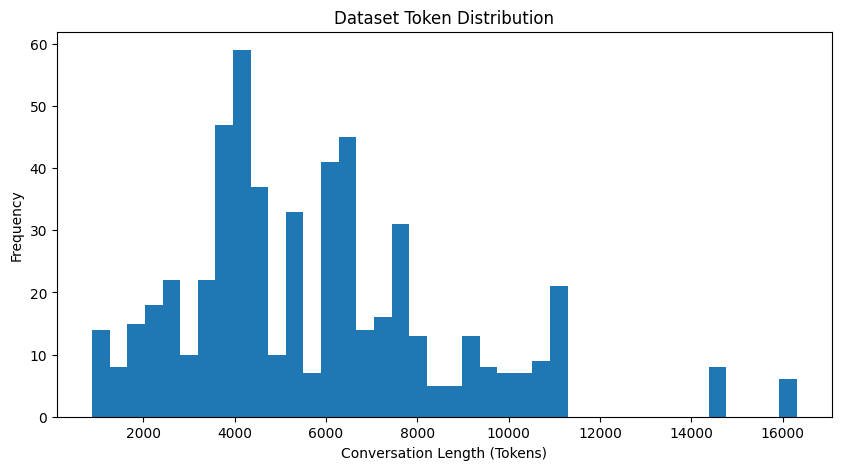

In [7]:
# ============================================================
# Dataset Statistics
# ============================================================

def count_tokens(example):
    text = ""

    for message in example["messages"]:
        text += message["content"] + "\n"

    return len(tokenizer(text, add_special_tokens=False)["input_ids"])


print("=" * 70)
print("Computing Dataset Statistics...")
print("=" * 70)

token_lengths = []

for sample in tqdm(dataset):

    token_lengths.append(
        count_tokens(sample)
    )

token_lengths = np.array(token_lengths)

print()

print("=" * 70)

print(f"Total Samples        : {len(dataset)}")
print(f"Average Tokens       : {np.mean(token_lengths):.2f}")
print(f"Median Tokens        : {np.median(token_lengths):.2f}")
print(f"95th Percentile      : {np.percentile(token_lengths,95):.2f}")
print(f"99th Percentile      : {np.percentile(token_lengths,99):.2f}")
print(f"Maximum Tokens       : {np.max(token_lengths)}")
print(f"Minimum Tokens       : {np.min(token_lengths)}")

print("=" * 70)

plt.figure(figsize=(10,5))

plt.hist(
    token_lengths,
    bins=40,
)

plt.xlabel("Conversation Length (Tokens)")
plt.ylabel("Frequency")
plt.title("Dataset Token Distribution")

plt.show()

In [8]:
# ============================================================
# Train / Validation / Test Split
# ============================================================

dataset = dataset.shuffle(seed=SEED)

# Split into Train and Remaining (Validation + Test)
train_test = dataset.train_test_split(
    test_size=(1 - TRAIN_SPLIT),
    seed=SEED,
)

train_dataset = train_test["train"]
remaining_dataset = train_test["test"]

# Split Remaining into Validation and Test
validation_ratio = VAL_SPLIT / (VAL_SPLIT + TEST_SPLIT)

validation_test = remaining_dataset.train_test_split(
    test_size=(1 - validation_ratio),
    seed=SEED,
)

validation_dataset = validation_test["train"]
test_dataset = validation_test["test"]

print("=" * 70)

print(f"Training Samples   : {len(train_dataset)} ({TRAIN_SPLIT*100:.0f}%)")
print(f"Validation Samples : {len(validation_dataset)} ({VAL_SPLIT*100:.0f}%)")
print(f"Test Samples       : {len(test_dataset)} ({TEST_SPLIT*100:.0f}%)")

print("=" * 70)

Training Samples   : 440 (80%)
Validation Samples : 55 (10%)
Test Samples       : 56 (10%)


In [9]:
# ============================================================
# Apply Chat Template
# ============================================================

def formatting_prompts_func(examples):

    conversations = examples["messages"]

    texts = [

        tokenizer.apply_chat_template(
            conversation,
            tokenize=False,
            add_generation_prompt=False,
        )

        for conversation in conversations

    ]

    return {

        "text": texts,

    }


train_dataset = train_dataset.map(
    formatting_prompts_func,
    batched=True,
)

validation_dataset = validation_dataset.map(
    formatting_prompts_func,
    batched=True,
)

test_dataset = test_dataset.map(
    formatting_prompts_func,
    batched=True,
)

print("=" * 70)
print("Chat Template Applied")
print("=" * 70)

print(train_dataset[0]["text"])

Map:   0%|          | 0/440 [00:00<?, ? examples/s]

Map:   0%|          | 0/55 [00:00<?, ? examples/s]

Map:   0%|          | 0/56 [00:00<?, ? examples/s]

Chat Template Applied
<｜begin▁of▁sentence｜>You are a Blue Team cybersecurity analyst specializing in architectural security assessments of enterprise software systems.

Your objective is to identify the single most effective defensive mitigation that addresses the root cause of the observed attack using the provided business context, architecture, workflow, trust boundaries, and source code.

Perform a structured architectural analysis before reaching a conclusion.

During your analysis:

• Identify the canonical security boundary of the application.
• Follow the end-to-end business workflow.
• Track how security-critical information is transformed between components.
• Distinguish architectural weaknesses from implementation details.
• Eliminate competing defensive hypotheses before selecting the final defense.
• Base every conclusion only on the supplied information.

Do not assume undocumented behavior.

Do not invent vulnerabilities, mitigations, or architectural details that are n

In [10]:
training_args = SFTConfig(

    output_dir=OUTPUT_DIR,

    max_length=MAX_SEQ_LENGTH,

    dataset_text_field="text",

    packing=False,

    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=1,

    gradient_accumulation_steps=GRAD_ACCUM,

    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    warmup_ratio=WARMUP_RATIO,

    num_train_epochs=EPOCHS,

    logging_steps=LOGGING_STEPS,
    logging_strategy="steps",

    eval_strategy="epoch",

    save_strategy="epoch",
    save_total_limit=SAVE_TOTAL_LIMIT,

    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,

    bf16=torch.cuda.is_bf16_supported(),
    fp16=not torch.cuda.is_bf16_supported(),

    optim="adamw_8bit",
    lr_scheduler_type="cosine",

    dataloader_num_workers=0,
    dataloader_pin_memory=False,

    report_to="none",

    seed=SEED,
)

trainer = SFTTrainer(

    model=model,

    args=training_args,

    train_dataset=train_dataset,
    eval_dataset=validation_dataset,

    processing_class=tokenizer,

)

trainer = train_on_responses_only(
    trainer,
    instruction_part="<｜User｜>",
    response_part="<｜Assistant｜>",
)

print("=" * 70)
print("Trainer Ready")
print("=" * 70)

print("Training Samples   :", len(train_dataset))
print("Validation Samples :", len(validation_dataset))
print("Test Samples       :", len(test_dataset))
print("=" * 70)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Unsloth: Tokenizing ["text"] (num_proc=8):   0%|          | 0/440 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=8):   0%|          | 0/55 [00:00<?, ? examples/s]

🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


Map:   0%|          | 0/440 [00:00<?, ? examples/s]

Filter:   0%|          | 0/440 [00:00<?, ? examples/s]

Unsloth: Removed 138 out of 440 samples from train_dataset where all labels were -100 (no response marker found, usually truncation). This prevents NaN loss during training.


Map:   0%|          | 0/55 [00:00<?, ? examples/s]

Filter:   0%|          | 0/55 [00:00<?, ? examples/s]

Unsloth: Removed 19 out of 55 samples from eval_dataset where all labels were -100 (no response marker found, usually truncation). This prevents NaN loss during training.
Trainer Ready
Training Samples   : 440
Validation Samples : 55
Test Samples       : 56


In [11]:
print("=" * 70)
print("Starting Training")
print("=" * 70)

start_time = time.time()

trainer_stats = trainer.train()

training_time = time.time() - start_time

print("=" * 70)
print("Training Complete")
print("=" * 70)

print(f"Training Time : {training_time/60:.2f} minutes")
print(f"Training Loss : {trainer_stats.training_loss:.6f}")

print("=" * 70)

Starting Training


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 302 | Num Epochs = 3 | Total steps = 57
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 16
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 16 x 1) = 16
 "-____-"     Trainable parameters = 167,772,160 of 8,198,033,408 (2.05% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Epoch,Training Loss,Validation Loss
1,2.673024,1.690234
2,1.444587,1.496837
3,1.044926,1.504097


Unsloth: Restored added_tokens_decoder metadata in ./outputs/checkpoint-19/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in ./outputs/checkpoint-38/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in ./outputs/checkpoint-57/tokenizer_config.json.


Training Complete
Training Time : 256.84 minutes
Training Loss : 1.556187


In [12]:
# ============================================================
# Save Best Adapter
# ============================================================
import os

BEST_MODEL_DIR = os.path.join(OUTPUT_DIR, "best_adapter")

trainer.save_model(BEST_MODEL_DIR)
tokenizer.save_pretrained(BEST_MODEL_DIR)

print("=" * 70)
print("Best Adapter Saved")
print("=" * 70)

print(BEST_MODEL_DIR)

Unsloth: Restored added_tokens_decoder metadata in ./outputs/best_adapter/tokenizer_config.json.


Best Adapter Saved
./outputs/best_adapter


In [13]:
FastLanguageModel.for_inference(model)

model.eval()

def generate_response(messages):

    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
    ).to(model.device)

    generation_kwargs = {
        "max_new_tokens": 1024,
        "do_sample": DO_SAMPLE,
        "use_cache": True,
        "pad_token_id": tokenizer.eos_token_id,
        "eos_token_id": tokenizer.eos_token_id,
    }

    if DO_SAMPLE:
        generation_kwargs["temperature"] = TEMPERATURE
        generation_kwargs["top_p"] = TOP_P

    with torch.inference_mode():

        outputs = model.generate(
            **inputs,
            **generation_kwargs,
        )

    prediction = tokenizer.decode(
        outputs[0][inputs.input_ids.shape[1]:],
        skip_special_tokens=True,
    )
    del outputs
    del inputs
    gc.collect()
    torch.cuda.empty_cache()

    return prediction.strip()


print("=" * 70)
print("Inference Ready")
print("=" * 70)



Inference Ready


In [14]:
validation_predictions = []

print("=" * 70)
print("Generating Validation Predictions")
print("=" * 70)

for sample in tqdm(validation_dataset):

    messages = sample["messages"][:-1]

    ground_truth = sample["messages"][-1]["content"]

    start_time = time.time()

    prediction = generate_response(messages)

    latency = time.time() - start_time

    validation_predictions.append({

        "messages": messages,
        "ground_truth": ground_truth,
        "prediction": prediction,
        "latency": latency

    })

print("=" * 70)
print(f"Generated {len(validation_predictions)} Validation Predictions")
print("=" * 70)

Generating Validation Predictions


  0%|          | 0/55 [00:00<?, ?it/s]

Both `max_new_tokens` (=1024) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=1024) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=1024) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=1024) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/t

Generated 55 Validation Predictions


In [15]:
# ============================================================
# Cell 16 - Display Validation Example
# ============================================================

example = validation_predictions[0]

print("\n" + "=" * 80)
print("VALIDATION SAMPLE")
print("=" * 80)

print("\nINPUT")

for message in example["messages"]:

    print(f"\n[{message['role'].upper()}]")

    print(message["content"][:1500])

print("\n" + "=" * 80)
print("GROUND TRUTH")
print("=" * 80)

print(example["ground_truth"])

print("\n" + "=" * 80)
print("MODEL PREDICTION")
print("=" * 80)

print(example["prediction"])

print("=" * 80)


VALIDATION SAMPLE

INPUT

[SYSTEM]
You are a Blue Team cybersecurity analyst specializing in architectural security assessments of enterprise software systems.

Your objective is to identify the single most effective defensive mitigation that addresses the root cause of the observed attack using the provided business context, architecture, workflow, trust boundaries, and source code.

Perform a structured architectural analysis before reaching a conclusion.

During your analysis:

• Identify the canonical security boundary of the application.
• Follow the end-to-end business workflow.
• Track how security-critical information is transformed between components.
• Distinguish architectural weaknesses from implementation details.
• Eliminate competing defensive hypotheses before selecting the final defense.
• Base every conclusion only on the supplied information.

Do not assume undocumented behavior.

Do not invent vulnerabilities, mitigations, or architectural details that are not supp

In [16]:
# ============================================================
# Cell 17 - Robust Evaluation Helper Functions (Defense Model)
# Compatible with:
# - DeepSeek Coder
# - DeepSeek R1
# - DeepSeek-R1-Distill-Qwen
# - Qwen
# - Llama
# ============================================================

import re

SECTION_HEADERS = [
    "correct defense:"
    "correct defense"
    "defense",
    "reasoning",
    "wrong_actions",
    "wrong_actions:"
    "wrong_action_reasoning",
    "wrong_action_reasoning:",
]


# ------------------------------------------------------------
# Clean generated text
# ------------------------------------------------------------
def clean_prediction(text):

    if text is None:
        return ""

    text = str(text)

    # --------------------------------------------------------
    # Remove reasoning / thinking blocks
    # --------------------------------------------------------
    text = re.sub(
        r"<think>.*?</think>",
        "",
        text,
        flags=re.DOTALL | re.IGNORECASE,
    )

    # --------------------------------------------------------
    # Remove common chat template tokens
    # --------------------------------------------------------
    SPECIAL_TOKENS = [

        # DeepSeek
        "<｜begin▁of▁sentence｜>",
        "<｜end▁of▁sentence｜>",
        "<｜User｜>",
        "<｜Assistant｜>",

        # Older DeepSeek
        "<|EOT|>",

        # Qwen
        "<|im_start|>",
        "<|im_end|>",

        # Llama
        "<|begin_of_text|>",
        "<|end_of_text|>",
        "<|eot_id|>",
        "<|start_header_id|>",
        "<|end_header_id|>",

        # Generic
        "<s>",
        "</s>",
        "<bos>",
        "<eos>",
    ]

    for token in SPECIAL_TOKENS:
        text = text.replace(token, "")

    # Remove any remaining special tokens
    text = re.sub(
        r"<[^>\n]+>",
        "",
        text,
    )

    # Remove duplicated headings
    text = re.sub(
        r"^\s*#{1,6}\s*(Instruction|Response)\s*:?\s*$",
        "",
        text,
        flags=re.MULTILINE | re.IGNORECASE,
    )

    # Remove markdown formatting
    text = re.sub(r"\*\*(.*?)\*\*", r"\1", text)
    text = re.sub(r"__(.*?)__", r"\1", text)
    text = re.sub(r"`(.*?)`", r"\1", text)

    # Normalize newlines
    text = text.replace("\r\n", "\n")
    text = text.replace("\r", "\n")

    # Collapse excessive blank lines
    text = re.sub(r"\n{3,}", "\n\n", text)

    return text.strip()


# ------------------------------------------------------------
# Normalize text
# ------------------------------------------------------------
def normalize(text):

    text = clean_prediction(text)

    text = text.lower()

    text = re.sub(r"\s+", " ", text)

    return text.strip()


# ------------------------------------------------------------
# Generic Section Extractor
# ------------------------------------------------------------
def _extract_section(text, section_name):
    """
    Robust section extractor.

    Supports headers such as:

        Defense:
        ### Defense:
        ## Defense :
        - Defense:
        * Defense:

        Wrong_Actions:
        Wrong Actions:
        Wrong-Actions:
        Wrong Action(s):

        Wrong_Action_Reasoning:
        Wrong Action Reasoning:
        Wrong-Action-Reasoning:
    """

    text = clean_prediction(text)

    header_patterns = {

        "defense":
            r"defense",

        "reasoning":
            r"reasoning",

        "wrong_actions":
            r"wrong(?:[-_\s]+)?actions?(?:\(\s*s\s*\))?",

        "wrong_action_reasoning":
            r"wrong(?:[-_\s]+)?action(?:[-_\s]+)?reasonings?",
    }

    current_header = header_patterns.get(
        section_name,
        re.escape(section_name),
    )

    all_headers = "|".join(
        f"(?:{v})"
        for v in header_patterns.values()
    )

    pattern = rf"""
        (?:^|\n)

        \s*

        (?:[#>*\-•]+\s*)?

        {current_header}

        \s*[:\-]?\s*

        (.*?)

        (?=
            \n
            \s*
            (?:[#>*\-•]+\s*)?
            (?:{all_headers})
            \s*[:\-]?

            |

            \Z
        )
    """

    match = re.search(
        pattern,
        text,
        flags=(
            re.IGNORECASE
            | re.MULTILINE
            | re.DOTALL
            | re.VERBOSE
        ),
    )

    if not match:
        return ""

    return match.group(1).strip()

# ------------------------------------------------------------
# Individual extractors
# ------------------------------------------------------------
def extract_defense(text):
    """
    Extract the defense name.
    """

    value = _extract_section(text, "defense")

    if not value:
        return ""

    for line in value.splitlines():

        line = line.strip()

        line = re.sub(
            r"^(\-|\*|•|\d+[\.\)])\s*",
            "",
            line,
        ).strip()

        if line:
            return line

    return ""


def extract_reasoning(text):

    return _extract_section(text, "reasoning")


def extract_wrong_actions(text):

    return _extract_section(text, "wrong_actions")


def extract_wrong_action_reasoning(text):

    return _extract_section(text, "wrong_action_reasoning")


# ------------------------------------------------------------
# Parse wrong actions
# ------------------------------------------------------------
def parse_wrong_actions(text):

    block = extract_wrong_actions(text)

    actions = []

    for line in block.splitlines():

        line = line.strip()

        line = re.sub(
            r"^(\-|\*|•|\d+[\.\)])\s*",
            "",
            line,
        )

        if line:
            actions.append(normalize(line))

    return set(actions)


# ------------------------------------------------------------
# Structure validation
# ------------------------------------------------------------
def structure_correct(text):

    return all([
        extract_defense(text),
        extract_reasoning(text),
        extract_wrong_actions(text),
        extract_wrong_action_reasoning(text),
    ])


print("=" * 70)
print("Robust Evaluation Helper Functions Ready")
print("=" * 70)

Robust Evaluation Helper Functions Ready


In [17]:
# ============================================================
# Cell 18 - Unified Evaluation Function (Defense Model)
# DeepSeek Coder Version
# ============================================================

embedding_model = SentenceTransformer(
    "sentence-transformers/all-mpnet-base-v2"
)


def evaluate_predictions(predictions):

    defense_gt = []
    defense_pred = []

    reasoning_gt = []
    reasoning_pred = []

    wrong_reasoning_gt = []
    wrong_reasoning_pred = []

    wrong_action_scores = []

    structure_scores = []

    exact_matches = []

    latencies = []

    detailed_rows = []

    # ======================================================
    # Parse Predictions
    # ======================================================

    for sample in tqdm(predictions):

        gt = sample["ground_truth"]
        pred = sample["prediction"]

        # -----------------------------
        # Defense
        # -----------------------------

        gt_defense = normalize(extract_defense(gt))
        pred_defense = normalize(extract_defense(pred))

        defense_gt.append(gt_defense)
        defense_pred.append(pred_defense)

        # -----------------------------
        # Reasoning
        # -----------------------------

        gt_reasoning = clean_prediction(
            extract_reasoning(gt)
        )

        pred_reasoning = clean_prediction(
            extract_reasoning(pred)
        )

        if not pred_reasoning:
            pred_reasoning = "<EMPTY>"

        reasoning_gt.append(gt_reasoning)
        reasoning_pred.append(pred_reasoning)

        # -----------------------------
        # Wrong Action Reasoning
        # -----------------------------

        gt_wrong_reasoning = clean_prediction(
            extract_wrong_action_reasoning(gt)
        )

        pred_wrong_reasoning = clean_prediction(
            extract_wrong_action_reasoning(pred)
        )

        if not pred_wrong_reasoning:
            pred_wrong_reasoning = "<EMPTY>"

        wrong_reasoning_gt.append(gt_wrong_reasoning)
        wrong_reasoning_pred.append(pred_wrong_reasoning)

        # -----------------------------
        # Wrong Actions
        # -----------------------------

        gt_actions = parse_wrong_actions(gt)
        pred_actions = parse_wrong_actions(pred)

        wrong_action_scores.append(
            int(gt_actions == pred_actions)
        )

        # -----------------------------
        # Structure / Exact Match
        # -----------------------------

        structure = int(
            structure_correct(pred)
        )

        exact = int(
            normalize(gt) == normalize(pred)
        )

        structure_scores.append(structure)
        exact_matches.append(exact)

        latencies.append(
            sample.get("latency", np.nan)
        )

        detailed_rows.append({

            "ground_truth_defense": gt_defense,
            "predicted_defense": pred_defense,
            "defense_correct": gt_defense == pred_defense,

            "ground_truth_reasoning": gt_reasoning,
            "predicted_reasoning": pred_reasoning,

            "ground_truth_wrong_actions": sorted(gt_actions),
            "predicted_wrong_actions": sorted(pred_actions),
            "wrong_actions_correct": gt_actions == pred_actions,

            "ground_truth_wrong_action_reasoning":
                gt_wrong_reasoning,

            "predicted_wrong_action_reasoning":
                pred_wrong_reasoning,

            "exact_match": bool(exact),

            "structure_score": structure,

        })

    # ======================================================
    # Semantic Similarity (Reasoning)
    # ======================================================

    if reasoning_gt:

        gt_reasoning_embeddings = embedding_model.encode(
            reasoning_gt,
            batch_size=32,
            convert_to_tensor=True,
            show_progress_bar=False,
        )

        pred_reasoning_embeddings = embedding_model.encode(
            reasoning_pred,
            batch_size=32,
            convert_to_tensor=True,
            show_progress_bar=False,
        )

        reasoning_similarity = float(

            util.cos_sim(
                pred_reasoning_embeddings,
                gt_reasoning_embeddings,
            ).diagonal().mean().item()

        )

    else:

        reasoning_similarity = 0.0

    # ======================================================
    # Semantic Similarity (Wrong Action Reasoning)
    # ======================================================

    if wrong_reasoning_gt:

        gt_wrong_embeddings = embedding_model.encode(
            wrong_reasoning_gt,
            batch_size=32,
            convert_to_tensor=True,
            show_progress_bar=False,
        )

        pred_wrong_embeddings = embedding_model.encode(
            wrong_reasoning_pred,
            batch_size=32,
            convert_to_tensor=True,
            show_progress_bar=False,
        )

        wrong_reasoning_similarity = float(

            util.cos_sim(
                pred_wrong_embeddings,
                gt_wrong_embeddings,
            ).diagonal().mean().item()

        )

    else:

        wrong_reasoning_similarity = 0.0

    # ======================================================
    # Final Metrics
    # ======================================================

    metrics = {

        "defense_accuracy": float(
            accuracy_score(
                defense_gt,
                defense_pred,
            )
        ) if defense_gt else 0.0,

        "reasoning_similarity":
            reasoning_similarity,

        "wrong_actions_accuracy": float(
            np.mean(wrong_action_scores)
        ) if wrong_action_scores else 0.0,

        "wrong_action_reasoning_similarity":
            wrong_reasoning_similarity,

        "exact_match": float(
            np.mean(exact_matches)
        ) if exact_matches else 0.0,

        "structure_score": float(
            np.mean(structure_scores)
        ) if structure_scores else 0.0,

        "average_latency": float(
            np.nanmean(latencies)
        ) if latencies else 0.0,

    }

    results_df = pd.DataFrame(detailed_rows)

    return metrics, results_df

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [18]:
# ============================================================
# Cell 19 - Evaluate Validation Set
# ============================================================

validation_metrics, validation_results = evaluate_predictions(validation_predictions)

print("=" * 70)
print("VALIDATION REPORT")
print("=" * 70)

for metric, value in validation_metrics.items():

    if isinstance(value, float):

        print(f"{metric:<25}: {value:.4f}")

    else:

        print(f"{metric:<25}: {value}")

print("=" * 70)

display(validation_results.head())

  0%|          | 0/55 [00:00<?, ?it/s]

VALIDATION REPORT
defense_accuracy         : 0.0000
reasoning_similarity     : -0.0530
wrong_actions_accuracy   : 0.4545
wrong_action_reasoning_similarity: 0.0891
exact_match              : 0.0000
structure_score          : 0.0000
average_latency          : 65.8619


,ground_truth_defense,predicted_defense,defense_correct,ground_truth_reasoning,predicted_reasoning,ground_truth_wrong_actions,predicted_wrong_actions,wrong_actions_correct,ground_truth_wrong_action_reasoning,predicted_wrong_action_reasoning,exact_match,structure_score
0,diagnostic_bundle_authorization_and_data_minim...,,False,Audit logging already exists and records bundl...,<EMPTY>,[],[],True,,<EMPTY>,False,0
1,bind_and_verify_execution_profile_identity,,False,1. ContainerLaunchService.cpp's resolveCpuShar...,<EMPTY>,[add_rate_limiting_to_profile_registry_lookups...,[],False,add_rate_limiting_to_profile_registry_lookups:...,<EMPTY>,False,0
2,lease_epoch_authorization_validation,,False,1. The platform intentionally separates author...,<EMPTY>,"[lease_epoch_projection_rebuilds, reservation_...",[],False,reservation_event_store_cleanup:\nRemoving his...,<EMPTY>,False,0
3,symlink_boundary_enforcement,,False,1. Archive validation correctly blocks traditi...,<EMPTY>,"[deploy_waf, enable_mtls, rotate_jwt_keys]",[],False,deploy_waf: The flaw is a filesystem trust iss...,<EMPTY>,False,0
4,preserve_approval_identity_and_category_throug...,,False,1. Independent approval authorities correctly ...,<EMPTY>,"[encrypt deploymentplan, perform rollout-time ...",[],False,Replace ApprovalRepository With A Different Da...,<EMPTY>,False,0


In [19]:
import gc

gc.collect()
torch.cuda.empty_cache()

In [20]:
# ============================================================
# Cell 20 - Generate Test Predictions
# ============================================================

test_predictions = []

print("=" * 70)
print("Generating Test Predictions")
print("=" * 70)

for sample in tqdm(test_dataset):

    messages = sample["messages"][:-1]

    ground_truth = sample["messages"][-1]["content"]

    start_time = time.time()

    prediction = generate_response(messages)

    latency = time.time() - start_time

    test_predictions.append({

        "messages": messages,

        "ground_truth": ground_truth,

        "prediction": prediction,

        "latency": latency,

    })

print("=" * 70)
print(f"Generated {len(test_predictions)} Test Predictions")
print("=" * 70)

example = test_predictions[0]

print("\nTEST SAMPLE")
print("=" * 70)

print("\nGROUND TRUTH\n")
print(example["ground_truth"])

print("\nMODEL PREDICTION\n")
print(example["prediction"])

print("\nLatency :", f"{example['latency']:.3f} sec")

print("=" * 70)

Generating Test Predictions


  0%|          | 0/56 [00:00<?, ?it/s]

Both `max_new_tokens` (=1024) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=1024) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=1024) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=1024) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/t

Generated 56 Test Predictions

TEST SAMPLE

GROUND TRUTH

Defense: optimized_bundle_provenance_validation

Reasoning:

1. The security invariant that must hold is: every optimized application bundle accepted for publication must be cryptographically bound to an approved application build. Approval should only transfer from the approved build to an optimized bundle after artifact lineage has been verified.

2. ReviewLedger.scala records valid approvals and ApprovedBuildStore.php stores approved application artifacts — these components are correct.

3. BundleComposer.zig correctly generates optimization metadata and BundleManifest.lua preserves approved and optimized artifact digests — the information needed to establish lineage exists.

4. PublicationAssembler.ex validates metadata consistency but never verifies artifact provenance. Approval is therefore transferred through metadata references instead of verified artifact lineage. This is where the invariant breaks.

5. MarketplacePubli

In [21]:
# ============================================================
# Cell 21 - Evaluate Test Set
# ============================================================

test_metrics, test_results = evaluate_predictions(
    test_predictions
)

print("=" * 70)
print("TEST REPORT")
print("=" * 70)

for metric, value in test_metrics.items():

    if isinstance(value, float):

        print(f"{metric:<25}: {value:.4f}")

    else:

        print(f"{metric:<25}: {value}")

print("=" * 70)

display(test_results.head())

  0%|          | 0/56 [00:00<?, ?it/s]

TEST REPORT
defense_accuracy         : 0.0000
reasoning_similarity     : -0.0436
wrong_actions_accuracy   : 0.3750
wrong_action_reasoning_similarity: 0.0685
exact_match              : 0.0000
structure_score          : 0.0000
average_latency          : 65.6968


,ground_truth_defense,predicted_defense,defense_correct,ground_truth_reasoning,predicted_reasoning,ground_truth_wrong_actions,predicted_wrong_actions,wrong_actions_correct,ground_truth_wrong_action_reasoning,predicted_wrong_action_reasoning,exact_match,structure_score
0,optimized_bundle_provenance_validation,,False,1. The security invariant that must hold is: e...,<EMPTY>,[],[],True,,<EMPTY>,False,0
1,authorization_epoch_preservation,,False,1. AuthorizationWorkflow correctly generates a...,<EMPTY>,[],[],True,,<EMPTY>,False,0
2,mission_safety_policy_integrity_verification,,False,1. MissionSafetyPolicy is generated with five ...,<EMPTY>,"[[""enforce_zone_checks_in_plan_repository"", ""r...",[],False,Enforcing zone checks in PlanRepository.store ...,<EMPTY>,False,0
3,workflow_state_revalidation_before_publication,,False,1. RevocationService.revoke_approval() sets wo...,<EMPTY>,"[add_rate_limiting, deploy_waf, rotate_signing...",[],False,rotate_signing_keys: The attacker replays a le...,<EMPTY>,False,0
4,firmware_manifest_hash_validation,,False,1. The security boundary of the system is the ...,<EMPTY>,"[firmware_retention_reduction, repository_acce...",[],False,firmware_retention_reduction:\nArtifact retent...,<EMPTY>,False,0


In [22]:
# ============================================================
# Cell 22 - Validation vs Test Comparison
# ============================================================

comparison = pd.DataFrame({

    "Metric": [

        "Defense Accuracy",
        "Reasoning Similarity",
        "Wrong Actions Accuracy",
        "Wrong Action Reasoning Similarity",
        "Exact Match",
        "Structure Score",
        "Average Latency",

    ],

    "Validation": [

        validation_metrics["defense_accuracy"],
        validation_metrics["reasoning_similarity"],
        validation_metrics["wrong_actions_accuracy"],
        validation_metrics["wrong_action_reasoning_similarity"],
        validation_metrics["exact_match"],
        validation_metrics["structure_score"],
        validation_metrics["average_latency"],

    ],

    "Test": [

        test_metrics["defense_accuracy"],
        test_metrics["reasoning_similarity"],
        test_metrics["wrong_actions_accuracy"],
        test_metrics["wrong_action_reasoning_similarity"],
        test_metrics["exact_match"],
        test_metrics["structure_score"],
        test_metrics["average_latency"],

    ],

})

display(comparison)

print("=" * 70)
print("Comparison Complete")
print("=" * 70)

,Metric,Validation,Test
0,Defense Accuracy,0.000000,0.000000
1,Reasoning Similarity,-0.052950,-0.043646
2,Wrong Actions Accuracy,0.454545,0.375000
3,Wrong Action Reasoning Similarity,0.089130,0.068537
4,Exact Match,0.000000,0.000000
5,Structure Score,0.000000,0.000000
6,Average Latency,65.861922,65.696846


Comparison Complete


In [23]:
# ============================================================
# Cell 23 - Save Evaluation Results
# ============================================================

RESULTS_DIR = "./results"

os.makedirs(
    RESULTS_DIR,
    exist_ok=True,
)

validation_results.to_csv(

    os.path.join(
        RESULTS_DIR,
        "validation_results.csv",
    ),

    index=False,

)

test_results.to_csv(

    os.path.join(
        RESULTS_DIR,
        "test_results.csv",
    ),

    index=False,

)

metrics = {

    "training_loss": float(
        trainer_stats.training_loss
    ),

    "validation": validation_metrics,

    "test": test_metrics,

}

with open(

    os.path.join(
        RESULTS_DIR,
        "metrics.json",
    ),

    "w",

) as f:

    json.dump(
        metrics,
        f,
        indent=4,
    )

print("=" * 70)
print("Results Saved Successfully")
print("=" * 70)

print(RESULTS_DIR)

Results Saved Successfully
./results


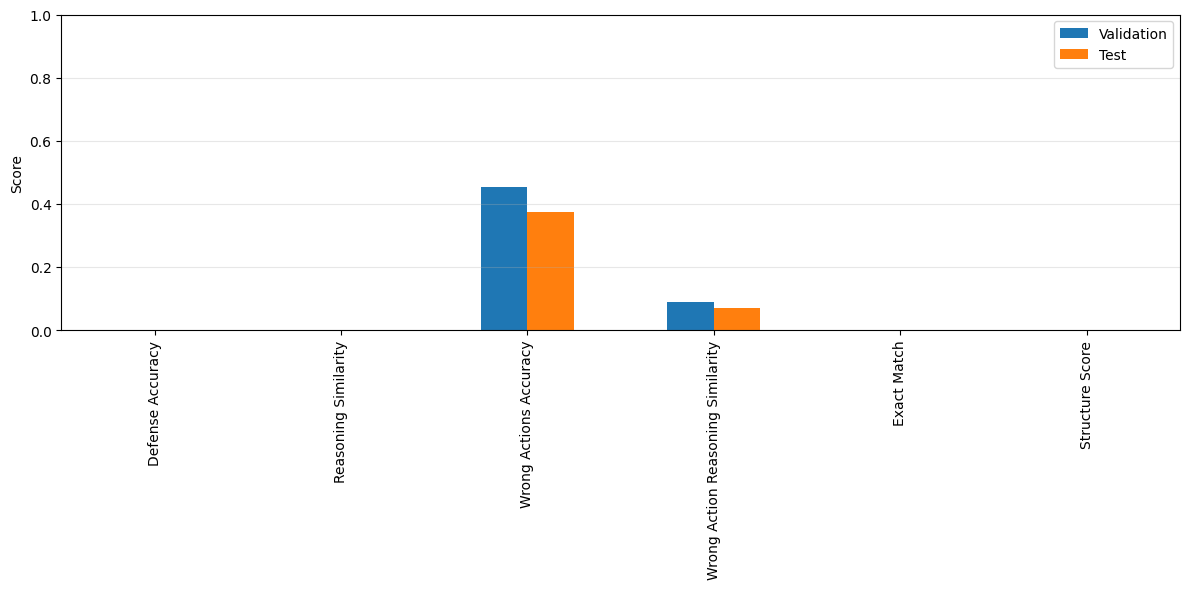

In [24]:
# ============================================================
# Cell 24 - Evaluation Visualizations
# ============================================================

metrics_df = pd.DataFrame({

    "Metric": [

        "Defense Accuracy",
        "Reasoning Similarity",
        "Wrong Actions Accuracy",
        "Wrong Action Reasoning Similarity",
        "Exact Match",
        "Structure Score",

    ],

    "Validation": [

        validation_metrics["defense_accuracy"],
        validation_metrics["reasoning_similarity"],
        validation_metrics["wrong_actions_accuracy"],
        validation_metrics["wrong_action_reasoning_similarity"],
        validation_metrics["exact_match"],
        validation_metrics["structure_score"],

    ],

    "Test": [

        test_metrics["defense_accuracy"],
        test_metrics["reasoning_similarity"],
        test_metrics["wrong_actions_accuracy"],
        test_metrics["wrong_action_reasoning_similarity"],
        test_metrics["exact_match"],
        test_metrics["structure_score"],

    ],

})

metrics_df.set_index("Metric").plot(
    kind="bar",
    figsize=(12, 6),
)

plt.ylabel("Score")
plt.xlabel("")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)
plt.legend(title="")
plt.tight_layout()

plt.show()